In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.api import VAR
from causalimpact import CausalImpact
import ruptures as rpt
import glob
import os

In [14]:
# Get all Excel files (e.g., .xlsx)
folder_path = r"C:\Users\bukovszki.viktor\JustNature\Szombathely_sensors\data"
files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))

# Read and concatenate all monthly files
df_list = [pd.read_excel(f, sheet_name=1) for f in files]
df = pd.concat(df_list, ignore_index=True)

# Optional: parse timestamp column if present
#df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time just in case
#df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,Mérés ideje,T2m\n°C,RH\n%,CO\nppm,NOx\nidx,O3\nppb,SO2\nppb,VOC\nidx,PM2.5\nug/m3,PM10\nug/m3,...,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,2024-03-13 11:40:00,14.0,49.6,2.0,1.0,0.7,2.5,100,10.5,10.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-03-13 11:50:00,15.2,42.9,1.9,1.0,0.5,1.3,108,10.5,10.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-03-13 12:00:00,14.6,44.9,2.0,1.0,0.7,0.7,111,10.8,11.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-03-13 12:10:00,15.0,45.1,1.9,1.0,0.6,0.6,111,9.2,9.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-03-13 12:20:00,14.9,44.0,2.0,1.0,0.6,0.2,116,9.5,9.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
#Clean up columns
dfc = df.drop(['Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24',
       'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28',
       'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32'], axis=1)
dfc.columns

Index(['Mérés ideje', 'T2m\n°C', 'RH\n%', 'CO\nppm', 'NOx\nidx', 'O3\nppb',
       'SO2\nppb', 'VOC\nidx', 'PM2.5\nug/m3', 'PM10\nug/m3', 'VWC\n%',
       'TS\n°C', 'Tölt\nVolt', 'Akku\nVolt', 'RSSI\n*-1'],
      dtype='object')

In [55]:
#dfc.set_index('Mérés ideje', inplace=True)

# Ensure 10-min resolution
dfd = dfc.resample("1D").mean()
dft = dfc.resample("10min").mean()
dfx = dfc.resample("1h").mean()

# Handle missing data (linear or Kalman filter if appropriate)
dfd = dfd.interpolate(method="time")
dft = dft.interpolate(method="time")
dfx = dfx.interpolate(method="time")

# Optional: Smooth outliers using rolling median
dfd = dfd.rolling(window=3, center=True, min_periods=1).median()
dft = dft.rolling(window=3, center=True, min_periods=1).median()
dfx = dfx.rolling(window=3, center=True, min_periods=1).median()

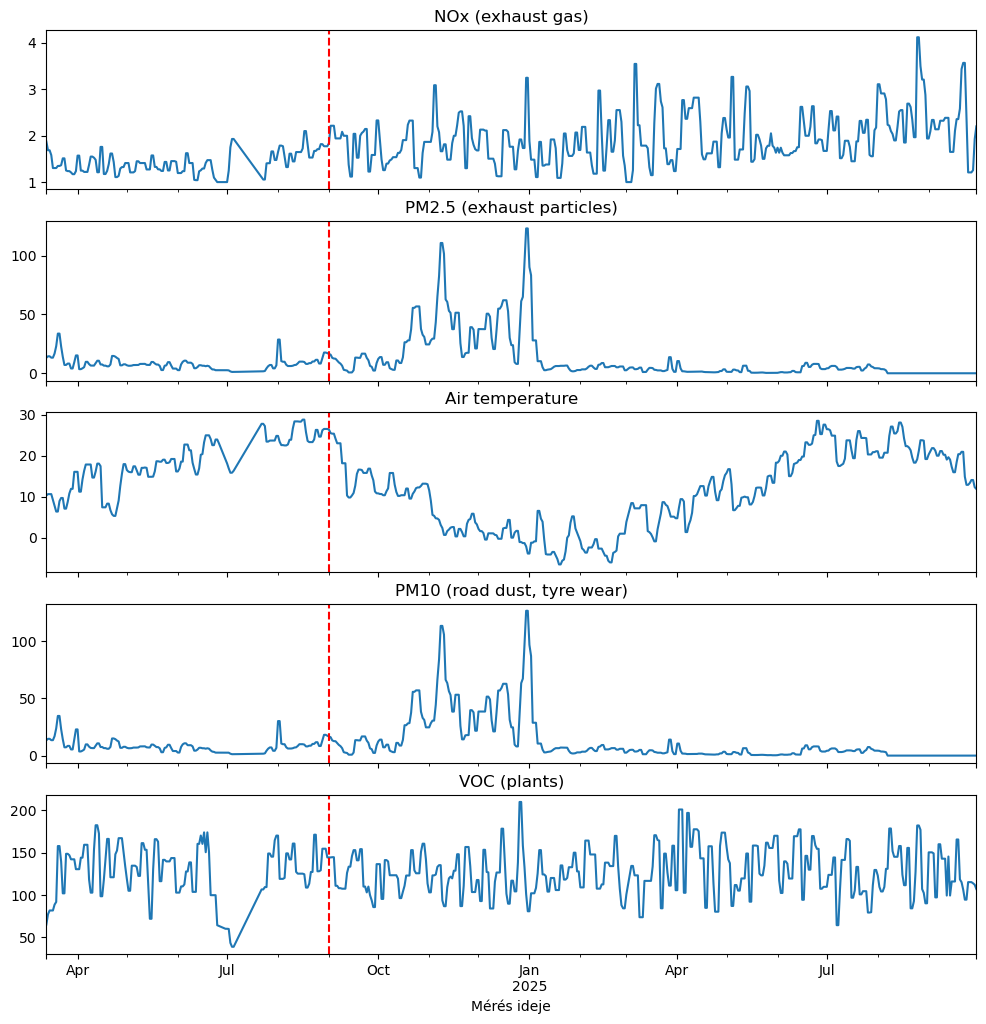

In [57]:
# Example for PM2.5 and Temperature
fig, ax = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
dfd["NOx\nidx"].plot(ax=ax[0], title="NOx (exhaust gas)")
dfd["PM2.5\nug/m3"].plot(ax=ax[1], title="PM2.5 (exhaust particles)")
dfd["T2m\n°C"].plot(ax=ax[2], title="Air temperature")
dfd["PM10\nug/m3"].plot(ax=ax[3], title="PM10 (road dust, tyre wear)")
dfd["VOC\nidx"].plot(ax=ax[4], title="VOC (plants)")

for a in ax:
    a.axvline("2024-09-01", color="red", linestyle="--", label="Greening Intervention")
plt.show()

In [83]:
# Months to consider: April–September
months_to_keep = [4, 5, 6, 7, 8, 9]

# Pre-intervention: 2024 April–September
pre = dft[(dft.index.year == 2024) & (dft.index.month.isin(months_to_keep))]

# Post-intervention: 2025 April–September
post = dft[(dft.index.year == 2025) & (dft.index.month.isin(months_to_keep))]

# Combine if needed
dft_seasonal = pd.concat([pre, post]).sort_index()

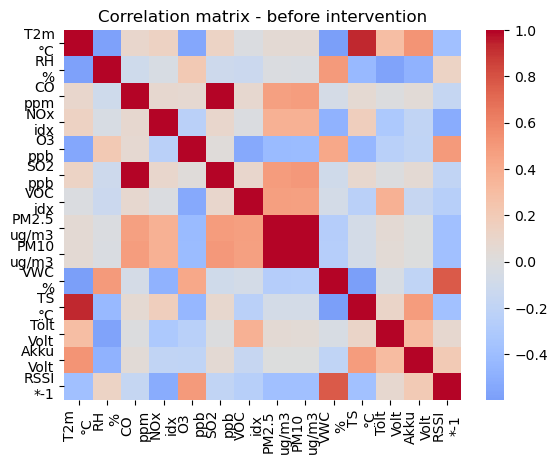

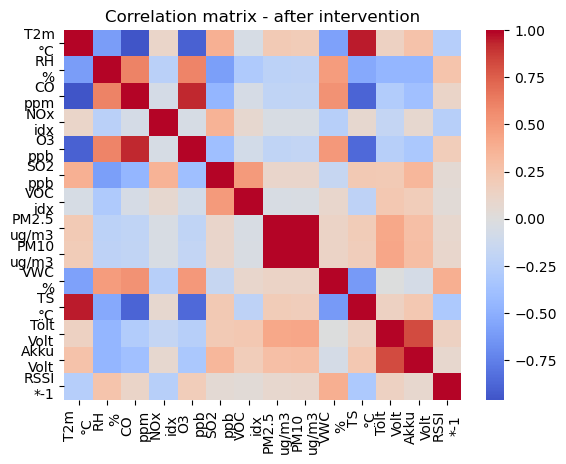

In [111]:
corr_before = pre.corr()
corr_after = post.corr()

sns.heatmap(corr_before, cmap="coolwarm", center=0)
plt.title("Correlation matrix - before intervention")
plt.show()

sns.heatmap(corr_after, cmap="coolwarm", center=0)
plt.title("Correlation matrix - after intervention")
plt.show()

In [30]:
result = adfuller(dft["PM2.5\nug/m3"].dropna())
print(f"ADF statistic: {result[0]}, p-value: {result[1]}")

ADF statistic: -6.920648364839337, p-value: 1.1488263651234272e-09


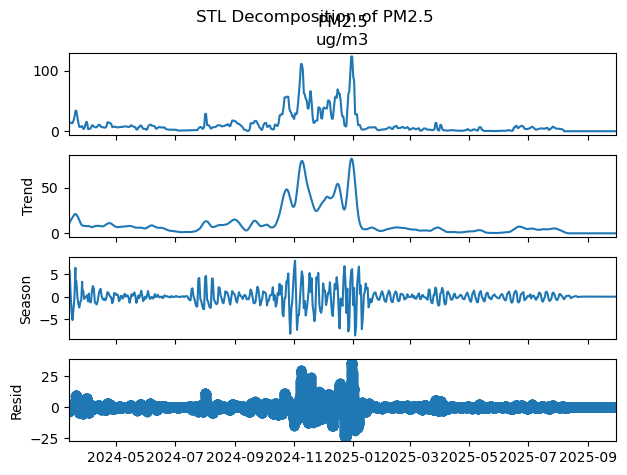

In [62]:
stl = STL(dft["PM2.5\nug/m3"].resample("1h").mean(), period=168)  # hourly resample
res = stl.fit()
res.plot()
plt.suptitle("STL Decomposition of PM2.5")
plt.show()

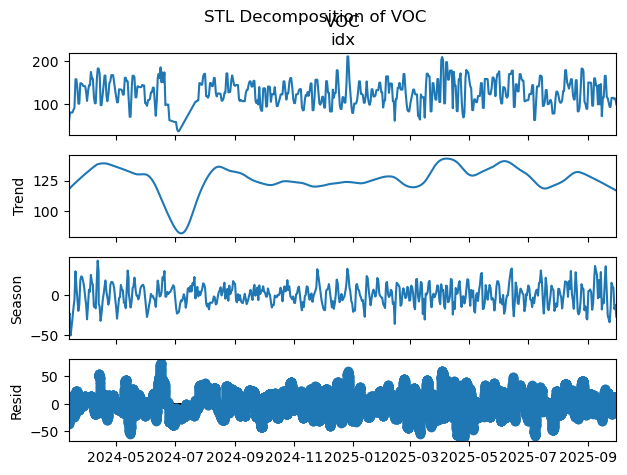

In [64]:
stl = STL(dft["VOC\nidx"].resample("1h").mean(), period=744)  # hourly resample
res = stl.fit()
res.plot()
plt.suptitle("STL Decomposition of VOC")
plt.show()

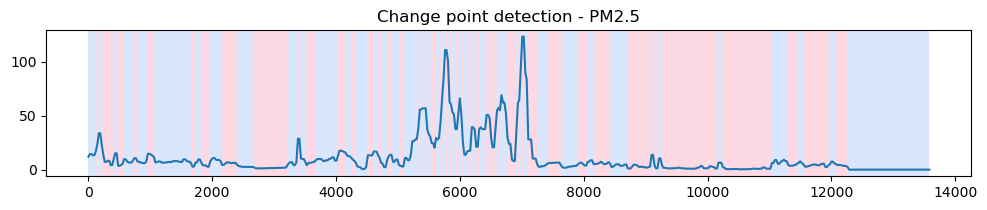

In [38]:
series = dft["PM2.5\nug/m3"].resample("1h").mean().dropna().values
model = rpt.Pelt(model="rbf").fit(series)
change_points = model.predict(pen=10)
rpt.display(series, change_points)
plt.title("Change point detection - PM2.5")
plt.show()

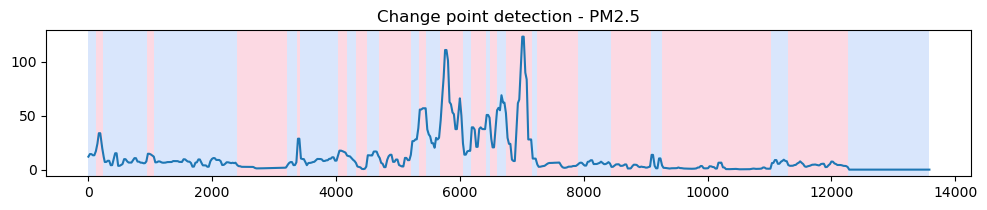

In [44]:
change_points = model.predict(pen=40)
rpt.display(series, change_points)
plt.title("Change point detection - PM2.5")
plt.show()

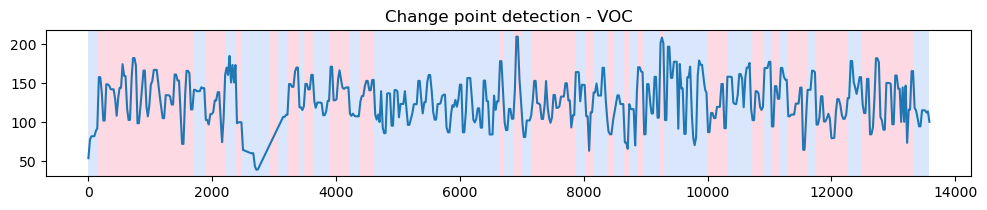

In [59]:
series = dft["VOC\nidx"].resample("1h").mean().dropna().values
model = rpt.Pelt(model="rbf").fit(series)
change_points = model.predict(pen=40)
rpt.display(series, change_points)
plt.title("Change point detection - VOC")
plt.show()

In [69]:
df_hourly = dfx

df_hourly["time"] = np.arange(len(df_hourly))
df_hourly["intervention"] = (df_hourly.index >= "2024-09-01").astype(int)
df_hourly["time_after"] = df_hourly["time"] * df_hourly["intervention"]
df_hourly["VOC"] = df_hourly["VOC\nidx"]

import statsmodels.formula.api as smf

model = smf.ols("Q('VOC') ~ time + intervention + time_after", data=df_hourly).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               Q('VOC')   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     61.20
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           2.71e-39
Time:                        14:34:45   Log-Likelihood:                -64987.
No. Observations:               13585   AIC:                         1.300e+05
Df Residuals:                   13581   BIC:                         1.300e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      128.5020      0.900    142.711   

In [70]:
dfd.columns

Index(['T2m\n°C', 'RH\n%', 'CO\nppm', 'NOx\nidx', 'O3\nppb', 'SO2\nppb',
       'VOC\nidx', 'PM2.5\nug/m3', 'PM10\nug/m3', 'VWC\n%', 'TS\n°C',
       'Tölt\nVolt', 'Akku\nVolt', 'RSSI\n*-1'],
      dtype='object')

In [94]:
# Resample to daily to reduce noise
df_daily = dft_seasonal.resample("D").mean()

# Ensure a continuous daily index
full_index = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq="D")
df_daily = df_daily.reindex(full_index)

# Fill NaNs (optional: forward-fill or interpolate)
df_daily = df_daily.interpolate(method="time")

# Select response + covariates
data = df_daily[["PM2.5\nug/m3", "T2m\n°C", "RH\n%", 'VOC\nidx']]

# Define pre/post periods as integer indices (recommended)
pre_period = [0, (pd.Timestamp("2024-09-30") - df_daily.index.min()).days]
post_period = [(pd.Timestamp("2025-04-01") - df_daily.index.min()).days, len(df_daily)-1]

# Run CausalImpact
impact = CausalImpact(data, pre_period, post_period)

print(impact.summary())
impact.plot()

AttributeError: 'NoneType' object has no attribute 'loc'

T-test p-value: 0.000


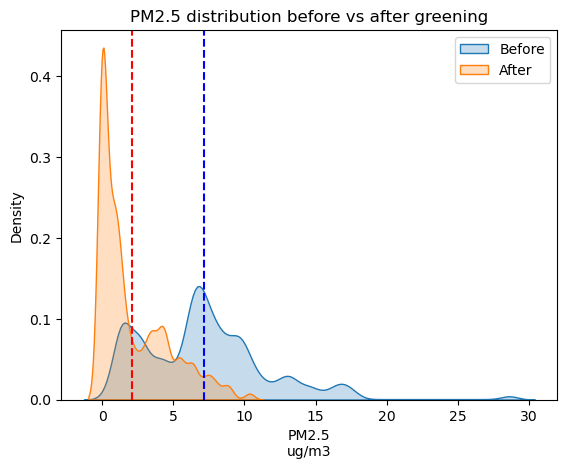

In [89]:
import scipy.stats as st

#before = dft.loc['2024-04-01':'2024-09-31']
#after = dft.loc['2025-04-01':'2025-09-31']

before_vals = pre["PM2.5\nug/m3"].dropna()
after_vals = post["PM2.5\nug/m3"].dropna()

t_stat, p_val = st.ttest_ind(before_vals, after_vals, equal_var=False)
print(f"T-test p-value: {p_val:.3f}")

sns.kdeplot(before_vals, label="Before", fill=True)
sns.kdeplot(after_vals, label="After", fill=True)
plt.axvline(before_vals.mean(), color="blue", linestyle="--")
plt.axvline(after_vals.mean(), color="red", linestyle="--")
plt.legend()
plt.title("PM2.5 distribution before vs after greening")
plt.show()

T-test p-value: 0.000


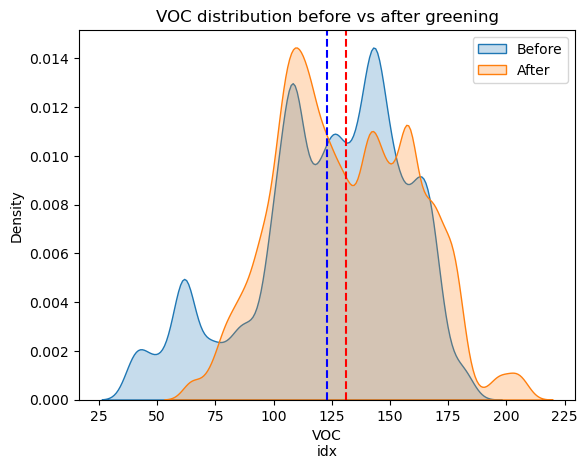

In [90]:
before_vals = pre["VOC\nidx"].dropna()
after_vals = post["VOC\nidx"].dropna()

t_stat, p_val = st.ttest_ind(before_vals, after_vals, equal_var=False)
print(f"T-test p-value: {p_val:.3f}")

sns.kdeplot(before_vals, label="Before", fill=True)
sns.kdeplot(after_vals, label="After", fill=True)
plt.axvline(before_vals.mean(), color="blue", linestyle="--")
plt.axvline(after_vals.mean(), color="red", linestyle="--")
plt.legend()
plt.title("VOC distribution before vs after greening")
plt.show()

T-test p-value: 0.000


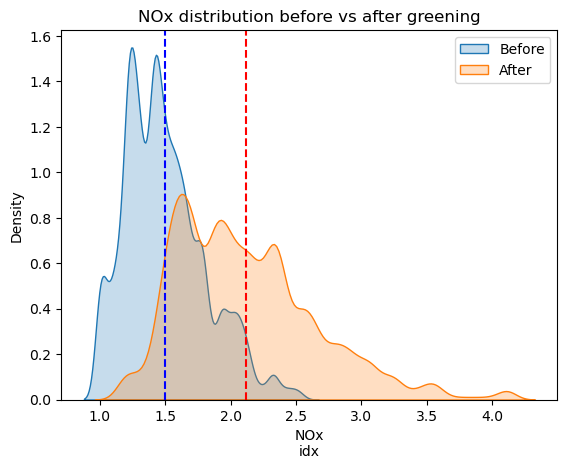

In [91]:
before_vals = pre["NOx\nidx"].dropna()
after_vals = post["NOx\nidx"].dropna()

t_stat, p_val = st.ttest_ind(before_vals, after_vals, equal_var=False)
print(f"T-test p-value: {p_val:.3f}")

sns.kdeplot(before_vals, label="Before", fill=True)
sns.kdeplot(after_vals, label="After", fill=True)
plt.axvline(before_vals.mean(), color="blue", linestyle="--")
plt.axvline(after_vals.mean(), color="red", linestyle="--")
plt.legend()
plt.title("NOx distribution before vs after greening")
plt.show()

T-test p-value: 0.000


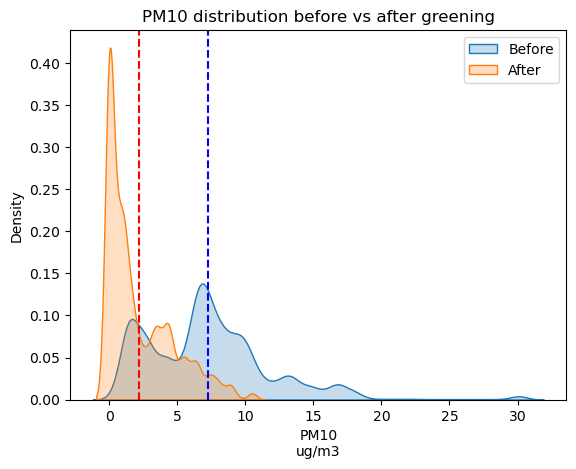

In [92]:
before_vals = pre["PM10\nug/m3"].dropna()
after_vals = post["PM10\nug/m3"].dropna()

t_stat, p_val = st.ttest_ind(before_vals, after_vals, equal_var=False)
print(f"T-test p-value: {p_val:.3f}")

sns.kdeplot(before_vals, label="Before", fill=True)
sns.kdeplot(after_vals, label="After", fill=True)
plt.axvline(before_vals.mean(), color="blue", linestyle="--")
plt.axvline(after_vals.mean(), color="red", linestyle="--")
plt.legend()
plt.title("PM10 distribution before vs after greening")
plt.show()

In [95]:
dft_seasonal.columns

Index(['T2m\n°C', 'RH\n%', 'CO\nppm', 'NOx\nidx', 'O3\nppb', 'SO2\nppb',
       'VOC\nidx', 'PM2.5\nug/m3', 'PM10\nug/m3', 'VWC\n%', 'TS\n°C',
       'Tölt\nVolt', 'Akku\nVolt', 'RSSI\n*-1'],
      dtype='object')

In [98]:
labels = ['Air_temperature', 'Relative_humidity', 'CO', 'NOX', 'O3', 'SO2', 'VOC', 'PM2.5', 'PM10', 'VWC', 'TS', 'Tölt', 'Akku', 'RSSI']
old = list(dft_seasonal.columns.values)
mapper = dict(zip(old,labels))
dft_seasonal.rename(mapper, axis=1, inplace=True)

In [102]:
dft_seasonal.columns

Index(['Air_temperature', 'Relative_humidity', 'CO', 'NOX', 'O3', 'SO2', 'VOC',
       'PM2.5', 'PM10', 'VWC', 'TS', 'Tölt', 'Akku', 'RSSI', 'time',
       'intervention', 'month'],
      dtype='object')

=== ITS Results for PM2.5 ===
                            OLS Regression Results                            
Dep. Variable:             Q('PM2.5')   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     9289.
Date:                Sun, 05 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:41:51   Log-Likelihood:            -1.4145e+05
No. Observations:               52561   AIC:                         2.829e+05
Df Residuals:                   52557   BIC:                         2.829e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6

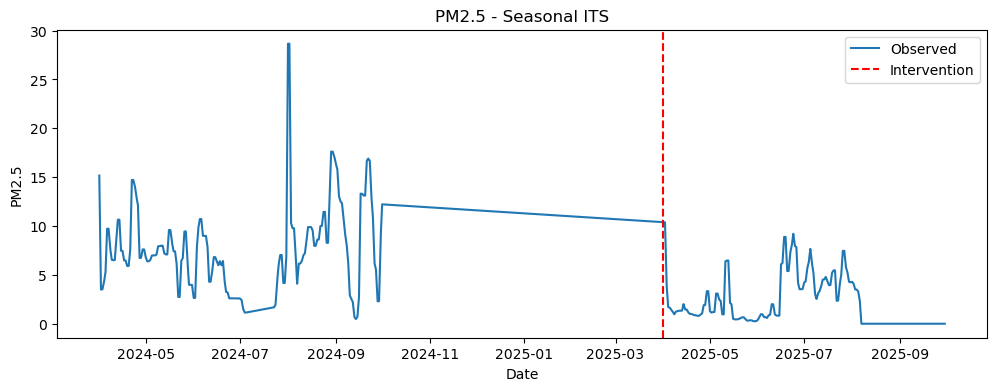

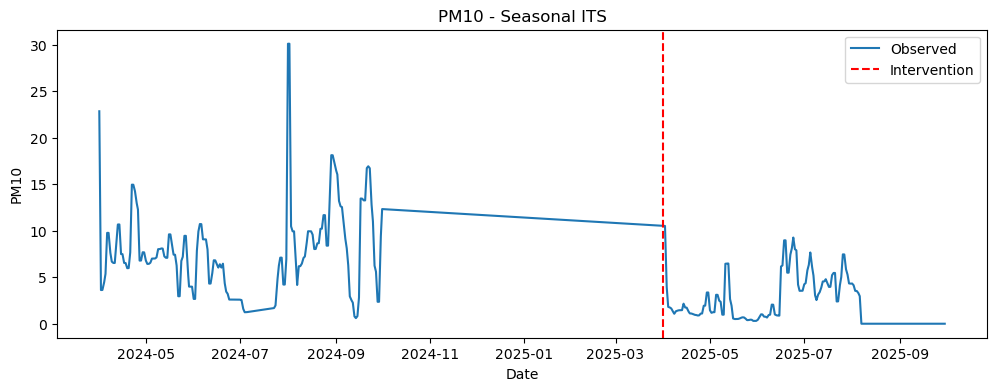

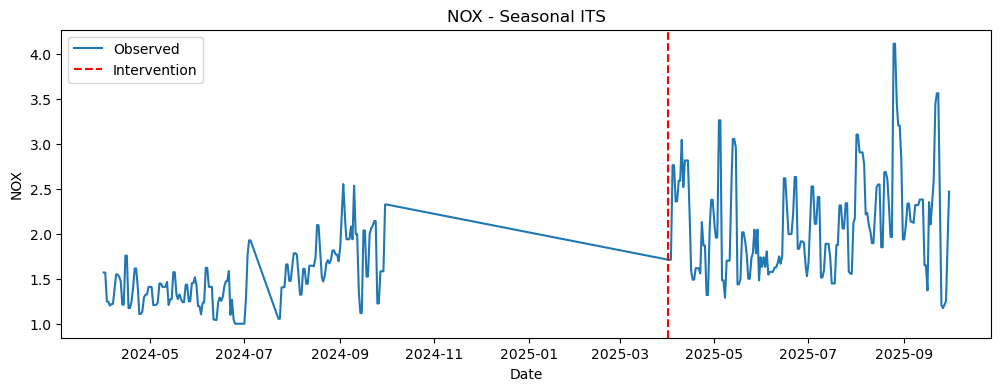

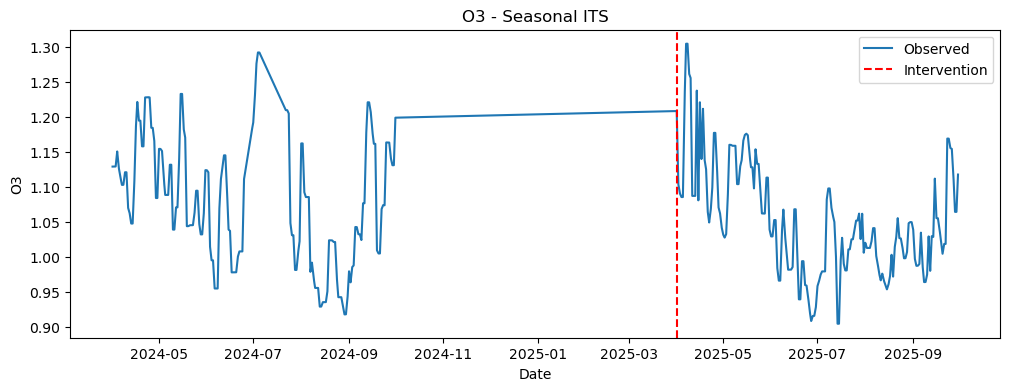

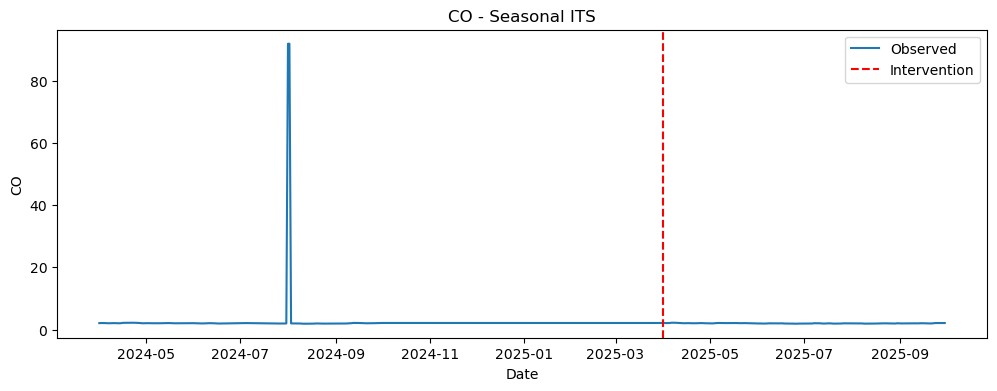

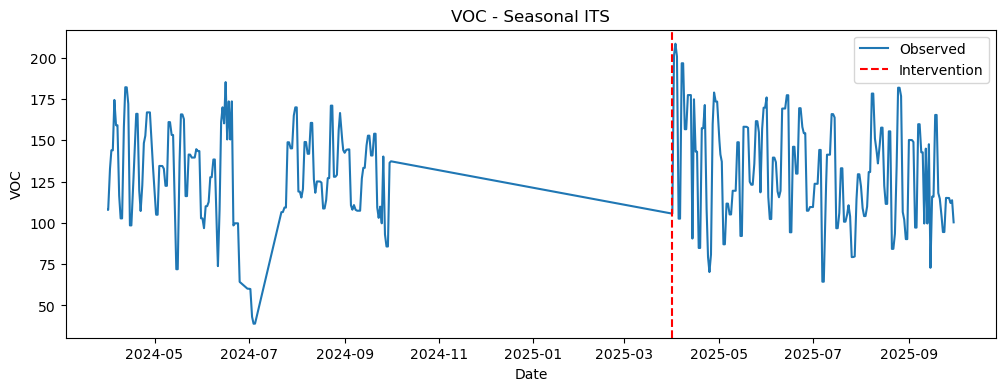

In [112]:
import seaborn as sns

# --------------------------
# 2. Create ITS variables
# --------------------------
dft_seasonal["time"] = np.arange(len(dft_seasonal))  # continuous time index
dft_seasonal["intervention"] = (dft_seasonal.index.year == 2025).astype(int)  # post-greening
dft_seasonal["time_after"] = dft_seasonal["time"] * dft_seasonal["intervention"]
dft_seasonal["month"] = dft_seasonal.index.month  # categorical month for seasonality

# --------------------------
# 3. Function to run ITS for one pollutant
# --------------------------
def run_its(df, response_var):
    formula = f"Q('{response_var}') ~ time + intervention + time_after"
    model = smf.ols(formula, data=df).fit()
    print(f"=== ITS Results for {response_var} ===")
    print(model.summary())
    return model

# --------------------------
# 4. Run ITS for multiple pollutants
# --------------------------
pollutants = ["PM2.5", "PM10", "NOX", "O3", "CO", "VOC"]  # adjust as needed
its_models = {}

for p in pollutants:
    its_models[p] = run_its(dft_seasonal, p)

# --------------------------
# 5. Plotting pre/post intervention
# --------------------------
def plot_pre_post(df, response_var):
    plt.figure(figsize=(12,4))
    sns.lineplot(x=df.index, y=df[response_var], label="Observed")
    plt.axvline(pd.Timestamp("2025-04-01"), color="red", linestyle="--", label="Intervention")
    plt.title(f"{response_var} - Seasonal ITS")
    plt.xlabel("Date")
    plt.ylabel(response_var)
    plt.legend()
    plt.show()

for p in pollutants:
    plot_pre_post(dft_seasonal, p)
